# PERTEMUAN 13 — Pengantar Topik Lanjutan: Deep Learning & NLP Dasar

**Nama:** Suryani Tangdiaga  
**NIM:** 250401020097  
**Kelas:** IF405

---

## Tujuan Pembelajaran
1. Mengenal dataset non-linear menggunakan `make_moons`.
2. Membangun dan melatih neural network sederhana dengan TensorFlow/Keras.
3. Mengevaluasi model dan memvisualisasikan kurva akurasi training dan validasi.
4. Mengenal NLP dasar melalui representasi TF-IDF.
5. Membuat klasifikasi sentimen sederhana menggunakan Logistic Regression.


## 1. Persiapan Library
Jalankan sel berikut. Jika menggunakan Google Colab, TensorFlow biasanya sudah tersedia.

In [1]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt

from sklearn.datasets import make_moons
from sklearn.model_selection import train_test_split
from sklearn.feature_extraction.text import TfidfVectorizer
from sklearn.linear_model import LogisticRegression
from sklearn.metrics import accuracy_score, classification_report, confusion_matrix


import tensorflow as tf
from tensorflow.keras.models import Sequential
from tensorflow.keras.layers import Dense
from tensorflow.keras import Sequential, Input
from tensorflow.keras.layers import Dense

print('TensorFlow version:', tf.__version__)


TensorFlow version: 2.21.0


## 2. Langkah 1 — Generate & Eksplorasi Dataset Non-Linear
Dataset `make_moons` digunakan untuk menunjukkan data dua kelas yang berbentuk bulan sabit sehingga tidak dapat dipisahkan dengan satu garis lurus.

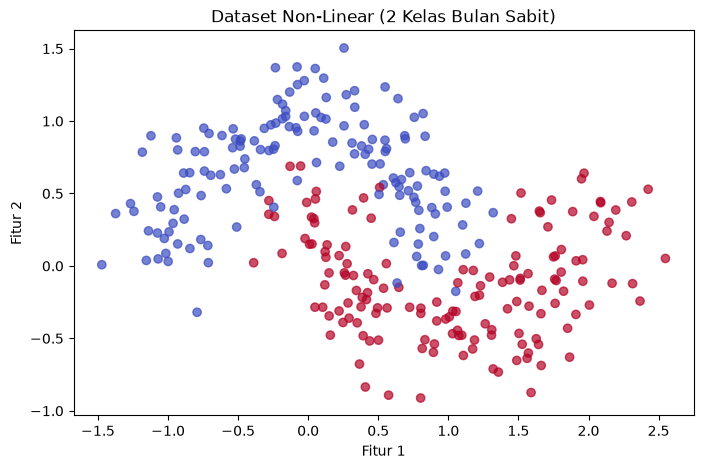

Jumlah data: 300
Jumlah fitur: 2
Kelas: [0 1]


In [2]:
X, y = make_moons(n_samples=300, noise=0.2, random_state=42)

plt.figure(figsize=(8, 5))
plt.scatter(X[:, 0], X[:, 1], c=y, cmap='coolwarm', alpha=0.7)
plt.title('Dataset Non-Linear (2 Kelas Bulan Sabit)')
plt.xlabel('Fitur 1')
plt.ylabel('Fitur 2')
plt.show()

print('Jumlah data:', len(X))
print('Jumlah fitur:', X.shape[1])
print('Kelas:', np.unique(y))


**Interpretasi:** kedua kelas membentuk pola melengkung dan saling berdekatan. Karena itu, model linear sederhana akan kesulitan memisahkan kedua kelas. Neural network dapat mempelajari batas keputusan non-linear.

## 3. Langkah 2 — Bangun & Latih Neural Network Sederhana
Model menggunakan dua hidden layer dengan aktivasi ReLU dan satu output dengan aktivasi Sigmoid.

In [3]:
X_tr, X_te, y_tr, y_te = train_test_split(
    X,
    y,
    test_size=0.2,
    random_state=42,
    stratify=y
)

model = Sequential([
    Input(shape=(2,)),
    Dense(16, activation='relu'),
    Dense(8, activation='relu'),
    Dense(1, activation='sigmoid')
])

model.compile(
    optimizer='adam',
    loss='binary_crossentropy',
    metrics=['accuracy']
)

model.summary()

history = model.fit(
    X_tr,
    y_tr,
    epochs=30,
    validation_split=0.2,
    verbose=0
)

print('Training selesai.')

Model: "sequential"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━┓
┃ Layer (type)                         ┃ Output Shape                ┃         Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━┩
│ dense (Dense)                        │ (None, 16)                  │              48 │
├──────────────────────────────────────┼─────────────────────────────┼─────────────────┤
│ dense_1 (Dense)                      │ (None, 8)                   │             136 │
├──────────────────────────────────────┼─────────────────────────────┼─────────────────┤
│ dense_2 (Dense)                      │ (None, 1)                   │               9 │
└──────────────────────────────────────┴─────────────────────────────┴─────────────────┘

 Total params: 193 (772.00 B)

 Trainable params: 193 (772.00 B)

 Non-trainable params: 0 (0.00 B)

Training selesai.


## 4. Langkah 3 — Evaluasi & Visualisasi Kurva Belajar

Akurasi pada data uji: 0.783
Loss pada data uji: 0.408


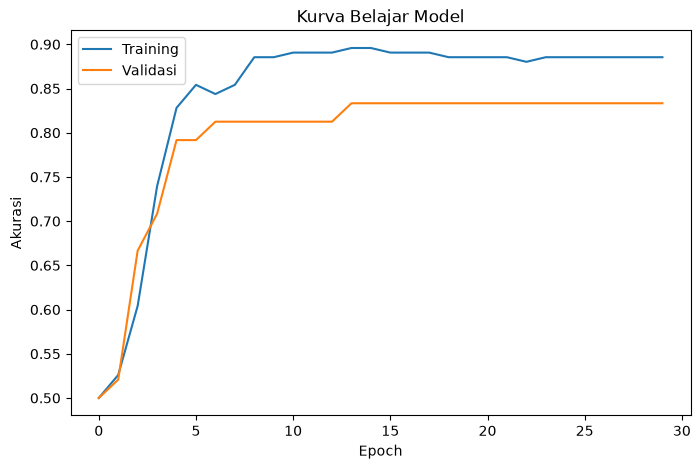

In [4]:
loss, acc = model.evaluate(X_te, y_te, verbose=0)
print(f'Akurasi pada data uji: {acc:.3f}')
print(f'Loss pada data uji: {loss:.3f}')

plt.figure(figsize=(8, 5))
plt.plot(history.history['accuracy'], label='Training')
plt.plot(history.history['val_accuracy'], label='Validasi')
plt.xlabel('Epoch')
plt.ylabel('Akurasi')
plt.legend()
plt.title('Kurva Belajar Model')
plt.show()


### Interpretasi Kurva Belajar
Jika akurasi training dan validasi sama-sama meningkat serta relatif berdekatan, model belajar dengan baik. Jika akurasi training jauh lebih tinggi daripada validasi, hal tersebut dapat menjadi indikasi overfitting.

## 5. Prediksi Dataset Non-Linear

In [5]:
prob = model.predict(X_te, verbose=0).ravel()
pred = (prob >= 0.5).astype(int)

print('Akurasi:', accuracy_score(y_te, pred))
print('\nConfusion Matrix:')
print(confusion_matrix(y_te, pred))

hasil_nn = pd.DataFrame({
    'Aktual': y_te[:10],
    'Prediksi': pred[:10],
    'Probabilitas Kelas 1': prob[:10]
})
hasil_nn


Akurasi: 0.7833333333333333

Confusion Matrix:
[[22  8]
 [ 5 25]]


,Aktual,Prediksi,Probabilitas Kelas 1
0,0,0,0.116477
1,0,0,0.074906
2,0,0,0.190042
3,0,0,0.120964
4,0,0,0.111207
5,0,0,0.099462
6,1,1,0.782577
7,0,1,0.645420
8,1,1,0.807397
9,0,0,0.107464


## 6. Langkah 4 — Siapkan Dataset Ulasan Produk
Dataset berikut berisi contoh ulasan produk dengan label sentimen sederhana: `1 = positif` dan `0 = negatif`.

In [6]:
ulasan = [
    'Barangnya bagus banget, pengiriman cepat',
    'Kualitas jelek, tidak sesuai deskripsi',
    'Sangat puas, akan beli lagi',
    'Kecewa, barang rusak saat sampai',
    'Recommended, harga sesuai kualitas',
    'Buruk sekali, tidak sesuai ekspektasi',
    'Pelayanan cepat dan barang sangat bagus',
    'Produk berkualitas dan pengiriman aman',
    'Saya suka produknya, sangat memuaskan',
    'Barang datang tepat waktu dan bagus',
    'Kualitas produk sangat baik',
    'Harga murah dan kualitas bagus',
    'Produk sesuai dengan yang saya harapkan',
    'Pelayanan penjual sangat ramah',
    'Pengiriman cepat, barang aman',
    'Barang jelek dan mudah rusak',
    'Tidak puas dengan produk ini',
    'Produk rusak ketika diterima',
    'Sangat mengecewakan dan tidak direkomendasikan',
    'Kualitas buruk dan tidak sesuai foto',
    'Produk sangat bagus dan bermanfaat',
    'Saya sangat senang dengan pembelian ini',
    'Barang sesuai pesanan dan berkualitas',
    'Pengiriman aman dan pelayanan baik',
    'Produk memuaskan sekali',
    'Barang tidak berfungsi dengan baik',
    'Saya kecewa dengan kualitas barang',
    'Produk tidak sesuai harapan',
    'Pengiriman terlambat dan barang rusak',
    'Tidak akan membeli produk ini lagi',
    'Kualitas bagus dan harga terjangkau',
    'Barang bagus sesuai deskripsi',
    'Pelayanan sangat cepat dan ramah',
    'Produk memuaskan dan berkualitas',
    'Barang buruk dan mengecewakan',
    'Produk rusak dan tidak bisa digunakan',
    'Sangat puas dengan pelayanan toko',
    'Barang bagus, saya suka sekali',
    'Produk berkualitas sesuai harga',
    'Tidak puas, kualitas sangat buruk'
]

label = [
    1,0,1,0,1,0,1,1,1,1,
    1,1,1,1,1,0,0,0,0,0,
    1,1,1,1,1,0,0,0,0,0,
    1,1,1,1,0,0,1,1,1,0
]

df_sentimen = pd.DataFrame({'Ulasan': ulasan, 'Label': label})
df_sentimen['Sentimen'] = df_sentimen['Label'].map({1: 'Positif', 0: 'Negatif'})
df_sentimen.head(10)


,Ulasan,Label,Sentimen
0,"Barangnya bagus banget, pengiriman cepat",1,Positif
1,"Kualitas jelek, tidak sesuai deskripsi",0,Negatif
2,"Sangat puas, akan beli lagi",1,Positif
3,"Kecewa, barang rusak saat sampai",0,Negatif
4,"Recommended, harga sesuai kualitas",1,Positif
5,"Buruk sekali, tidak sesuai ekspektasi",0,Negatif
6,Pelayanan cepat dan barang sangat bagus,1,Positif
7,Produk berkualitas dan pengiriman aman,1,Positif
8,"Saya suka produknya, sangat memuaskan",1,Positif
9,Barang datang tepat waktu dan bagus,1,Positif


## 7. Langkah 5 — Ubah Teks Menjadi TF-IDF
TF-IDF mengubah teks menjadi representasi numerik berdasarkan pentingnya kata dalam kumpulan dokumen.

In [7]:
tfidf = TfidfVectorizer()
X_text = tfidf.fit_transform(ulasan)

fitur = tfidf.get_feature_names_out()
print('Jumlah kata unik:', len(fitur))
print('10 fitur pertama:', fitur[:10])
print('Ukuran matriks TF-IDF:', X_text.shape)


Jumlah kata unik: 63
10 fitur pertama: ['akan' 'aman' 'bagus' 'baik' 'banget' 'barang' 'barangnya' 'beli'
 'berfungsi' 'berkualitas']
Ukuran matriks TF-IDF: (40, 63)


## 8. Langkah 6 — Latih Model Klasifikasi Sentimen & Evaluasi

In [8]:
X_train, X_test, y_train, y_test = train_test_split(
    X_text, label, test_size=0.2, random_state=42, stratify=label
)

model_sentimen = LogisticRegression(max_iter=1000)
model_sentimen.fit(X_train, y_train)

akurasi = model_sentimen.score(X_test, y_test)
print(f'Akurasi model sentimen: {akurasi:.3f}')

pred_test = model_sentimen.predict(X_test)
print('\nClassification Report:')
print(classification_report(y_test, pred_test, target_names=['Negatif', 'Positif'], zero_division=0))


Akurasi model sentimen: 0.750

Classification Report:
              precision    recall  f1-score   support

     Negatif       1.00      0.33      0.50         3
     Positif       0.71      1.00      0.83         5

    accuracy                           0.75         8
   macro avg       0.86      0.67      0.67         8
weighted avg       0.82      0.75      0.71         8



## 9. Pengujian dengan Kalimat Baru

In [9]:
kalimat_baru = [
    'Pelayanan sangat memuaskan dan ramah',
    'Barangnya rusak dan sangat mengecewakan',
    'Produk bagus dan sesuai dengan harga'
]

X_baru = tfidf.transform(kalimat_baru)
prediksi_baru = model_sentimen.predict(X_baru)
probabilitas_baru = model_sentimen.predict_proba(X_baru)

hasil_prediksi = pd.DataFrame({
    'Kalimat': kalimat_baru,
    'Prediksi': ['Positif' if p == 1 else 'Negatif' for p in prediksi_baru],
    'Probabilitas Positif': probabilitas_baru[:, 1]
})

hasil_prediksi


,Kalimat,Prediksi,Probabilitas Positif
0,Pelayanan sangat memuaskan dan ramah,Positif,0.765505
1,Barangnya rusak dan sangat mengecewakan,Positif,0.565603
2,Produk bagus dan sesuai dengan harga,Positif,0.732096


## 10. Kesimpulan

- Dataset `make_moons` menunjukkan contoh data non-linear yang cocok untuk demonstrasi neural network sederhana.
- Neural network dengan ReLU dan Sigmoid dapat mempelajari pola non-linear dan digunakan untuk klasifikasi biner.
- TF-IDF mengubah data teks menjadi fitur numerik yang dapat digunakan oleh algoritma machine learning.
- Logistic Regression dapat digunakan sebagai baseline sederhana untuk klasifikasi sentimen.
- Hasil prediksi kalimat baru menunjukkan bagaimana model dapat mengklasifikasikan teks menjadi sentimen positif atau negatif.
